# Proyek Klasifikasi Gambar: Shells or Pebbles: An Image Classification Dataset
- **Nama:** Abdul Syukur Kamaruddin
- **Email:** abdulsyukursyam@gmail.com
- **ID Dicoding:** abdlsykr

## Import Semua Packages/Library yang Digunakan

In [1]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler, Callback
import tensorflow as tf
import numpy as np
import os
import shutil
from sklearn.model_selection import train_test_split

## Data Preparation

### Data Loading

In [2]:
!pip install -q kaggle

from google.colab import files
files.upload()  # Upload file kaggle.json

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

!kaggle datasets download -d vencerlanz09/shells-or-pebbles-an-image-classification-dataset
!unzip shells-or-pebbles-an-image-classification-dataset.zip -d dataset/

print(os.listdir('dataset/'))

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/vencerlanz09/shells-or-pebbles-an-image-classification-dataset
License(s): CC-BY-SA-4.0
Archive:  shells-or-pebbles-an-image-classification-dataset.zip
  inflating: dataset/Pebbles/Pebbles (1).jpg  
  inflating: dataset/Pebbles/Pebbles (10).jpg  
  inflating: dataset/Pebbles/Pebbles (100).jpg  
  inflating: dataset/Pebbles/Pebbles (1000).jpg  
  inflating: dataset/Pebbles/Pebbles (1001).jpg  
  inflating: dataset/Pebbles/Pebbles (1002).jpg  
  inflating: dataset/Pebbles/Pebbles (1003).jpg  
  inflating: dataset/Pebbles/Pebbles (1004).jpg  
  inflating: dataset/Pebbles/Pebbles (1005).jpg  
  inflating: dataset/Pebbles/Pebbles (1006).jpg  
  inflating: dataset/Pebbles/Pebbles (1007).jpg  
  inflating: dataset/Pebbles/Pebbles (1008).jpg  
  inflating: dataset/Pebbles/Pebbles (1009).jpg  
  inflating: dataset/Pebbles/Pebbles (101).jpg  
  inflating: dataset/Pebbles/Pebbles (1010).jpg  
  inflating: dataset/Pebbl

### Data Preprocessing

#### Split Dataset

In [3]:
pebbles_path = 'dataset/Pebbles'
shells_path = 'dataset/Shells'

os.makedirs('dataset/train/Pebbles', exist_ok=True)
os.makedirs('dataset/train/Shells', exist_ok=True)
os.makedirs('dataset/test/Pebbles', exist_ok=True)
os.makedirs('dataset/test/Shells', exist_ok=True)

pebbles_files = [os.path.join(pebbles_path, f) for f in os.listdir(pebbles_path) if f.endswith('.jpg') or f.endswith('.png')]
shells_files = [os.path.join(shells_path, f) for f in os.listdir(shells_path) if f.endswith('.jpg') or f.endswith('.png')]

pebbles_train, pebbles_test = train_test_split(pebbles_files, test_size=0.2, random_state=42)
shells_train, shells_test = train_test_split(shells_files, test_size=0.2, random_state=42)

for file in pebbles_train:
    shutil.copy(file, 'dataset/train/Pebbles/')
for file in shells_train:
    shutil.copy(file, 'dataset/train/Shells/')
for file in pebbles_test:
    shutil.copy(file, 'dataset/test/Pebbles/')
for file in shells_test:
    shutil.copy(file, 'dataset/test/Shells/')


In [20]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.5, 1.5],
    validation_split=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'dataset/train', target_size=(299, 299), batch_size=32, class_mode='binary', subset='training'
)

validation_generator = val_datagen.flow_from_directory(
    'dataset/train', target_size=(299, 299), batch_size=32, class_mode='binary', subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    'dataset/test', target_size=(299, 299), batch_size=32, class_mode='binary'
)

steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = validation_generator.samples // validation_generator.batch_size


Found 2742 images belonging to 2 classes.
Found 684 images belonging to 2 classes.
Found 858 images belonging to 2 classes.


## Modelling

In [21]:
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

model = Sequential([
    base_model,
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.5),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

base_model.trainable = False
for layer in base_model.layers[-4:]:
    layer.trainable = True

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [22]:
class CustomCallbacks(Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        accuracy = logs.get("accuracy", 0)

        if accuracy > 0.85:
            print(f"\nPelatihan berhenti karena akurasi training ({accuracy:.4f}) telah melewati 0.85.")
            self.model.stop_training = True


In [23]:
def lr_scheduler(epoch, lr):
    if epoch > 30:
        return lr * 0.5
    return lr

lr_callback = LearningRateScheduler(lr_scheduler)

callbacks = [CustomCallbacks(), lr_callback]

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=callbacks
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 98s 990ms/step - accuracy: 0.6246 - loss: 1.2233 - val_accuracy: 0.8765 - val_loss: 0.4613 - learning_rate: 0.0010
Epoch 2/30
 1/85 ━━━━━━━━━━━━━━━━━━━━ 9s 117ms/step - accuracy: 0.8125 - loss: 0.5805

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8125 - loss: 0.5805 - val_accuracy: 0.8824 - val_loss: 0.4625 - learning_rate: 0.0010
Epoch 3/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.7656 - loss: 0.5132 - val_accuracy: 0.8958 - val_loss: 0.3024 - learning_rate: 0.0010
Epoch 4/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.7812 - loss: 0.3733 - val_accuracy: 0.9003 - val_loss: 0.3061 - learning_rate: 0.0010
Epoch 5/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 82s 972ms/step - accuracy: 0.7745 - loss: 0.4985 - val_accuracy: 0.9107 - val_loss: 0.2351 - learning_rate: 0.0010
Epoch 6/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.7500 - loss: 0.4735 - val_accuracy: 0.9107 - val_loss: 0.2362 - learning_rate: 0.0010
Epoch 7/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 129s 857ms/step - accuracy: 0.7927 - loss: 0.4356 - val_accuracy: 0.9137 - val_loss: 0.2388 - learning_rate: 0.0010
Epoch 8/30
 1/85 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.9062 - loss: 0.2578
Pelatihan berh

## Evaluasi dan Visualisasi

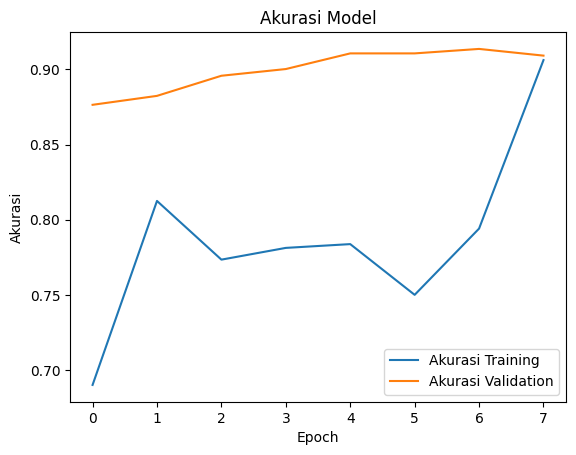

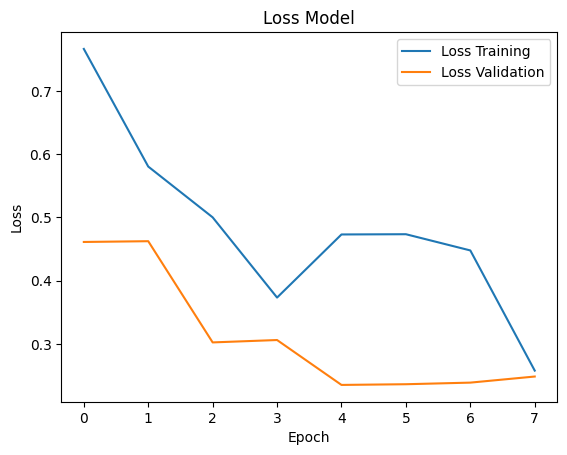

In [24]:
plt.plot(history.history['accuracy'], label='Akurasi Training')
plt.plot(history.history['val_accuracy'], label='Akurasi Validation')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend(loc='lower right')
plt.title('Akurasi Model')
plt.show()

plt.plot(history.history['loss'], label='Loss Training')
plt.plot(history.history['val_loss'], label='Loss Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Loss Model')
plt.show()


In [25]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"\nAkurasi pada data testing: {test_accuracy:.4f}")


27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 285ms/step - accuracy: 0.8505 - loss: 0.4463

Akurasi pada data testing: 0.8671


27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 384ms/step

Classification Report:
              precision    recall  f1-score   support

     Pebbles       0.65      0.64      0.65       549
      Shells       0.38      0.39      0.39       309

    accuracy                           0.55       858
   macro avg       0.52      0.52      0.52       858
weighted avg       0.55      0.55      0.55       858



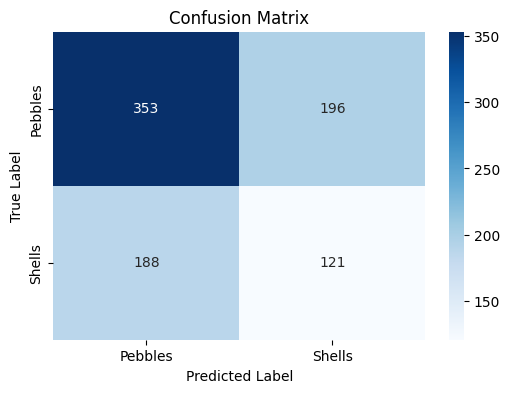

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Ambil prediksi dari model
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Label sebenarnya
y_true = test_generator.classes

# Nama kelas
class_labels = list(test_generator.class_indices.keys())

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


## Konversi Model

In [27]:
# Membuat labels.txt berdasarkan kelas dari train_generator
label_map = train_generator.class_indices
sorted_labels = sorted(label_map, key=label_map.get)  # Urut berdasarkan indeks

with open("labels.txt", "w") as f:
    for label in sorted_labels:
        f.write(label + "\n")

print("labels.txt berhasil dibuat dengan label:", sorted_labels)


labels.txt berhasil dibuat dengan label: ['Pebbles', 'Shells']


In [28]:
save_path = '/content/mymodel/'
tf.saved_model.save(model, save_path)

In [29]:
!pip install tensorflowjs

In [30]:
model.save('pebblesorshells.h5')

In [31]:
!tensorflowjs_converter --input_format=keras pebblesorshells.h5 tfjs_model

2025-05-12 09:36:49.962086: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747042609.994590    7202 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747042610.004671    7202 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
🌲 Try https://ydf.readthedocs.io, the successor of TensorFlow Decision Forests with more features and faster training!
failed to lookup keras version from the file,
    this is likely a weight only file


In [32]:
import os
os.listdir('tfjs_model')

['group1-shard2of22.bin',
 'group1-shard18of22.bin',
 'group1-shard11of22.bin',
 'group1-shard7of22.bin',
 'model.json',
 'group1-shard21of22.bin',
 'group1-shard10of22.bin',
 'group1-shard15of22.bin',
 'group1-shard13of22.bin',
 'group1-shard6of22.bin',
 'group1-shard1of22.bin',
 'group1-shard16of22.bin',
 'group1-shard20of22.bin',
 'group1-shard19of22.bin',
 'group1-shard12of22.bin',
 'group1-shard9of22.bin',
 'group1-shard17of22.bin',
 'group1-shard5of22.bin',
 'group1-shard22of22.bin',
 'group1-shard14of22.bin',
 'group1-shard4of22.bin',
 'group1-shard8of22.bin',
 'group1-shard3of22.bin']

In [33]:
# Memuat model Keras yang sudah disimpan
model = tf.keras.models.load_model('pebblesorshells.h5')

# Konversi model Keras ke TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model TensorFlow Lite ke file
with open('pebblesorshells_model.tflite', 'wb') as f:
    f.write(tflite_model)


Saved artifact at '/tmp/tmp3w883n0v'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132827841858448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132827841855952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132827841871504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132827841870544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132827841861520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132827841870928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132827841861904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132827841861136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132825021444752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132825021445520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1328250214459

In [34]:
pip freeze requirements.txt

absl-py==1.4.0
accelerate==1.6.0
aiohappyeyeballs==2.6.1
aiohttp==3.11.15
aiosignal==1.3.2
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.6
ale-py==0.11.0
altair==5.5.0
annotated-types==0.7.0
anyio==4.9.0
argon2-cffi==23.1.0
argon2-cffi-bindings==21.2.0
array_record==0.7.2
arviz==0.21.0
astropy==7.0.1
astropy-iers-data==0.2025.4.28.0.37.27
astunparse==1.6.3
atpublic==5.1
attrs==25.3.0
audioread==3.0.1
autograd==1.7.0
babel==2.17.0
backcall==0.2.0
backports.tarfile==1.2.0
beautifulsoup4==4.13.4
betterproto==2.0.0b6
bigframes==2.1.0
bigquery-magics==0.9.0
bleach==6.2.0
blinker==1.9.0
blis==1.3.0
blosc2==3.3.2
bokeh==3.7.2
Bottleneck==1.4.2
bqplot==0.12.44
branca==0.8.1
build==1.2.2.post1
CacheControl==0.14.3
cachetools==5.5.2
catalogue==2.0.10
certifi==2025.4.26
cffi==1.17.1
chardet==5.2.0
charset-normalizer==3.4.1
chex==0.1.89
clarabel==0.10.0
click==8.1.8
cloudpathlib==0.21.0
cloudpickle==3.1.1
cmake==3.31.6
cmdstanpy==1.2.5
colorcet==3.1.0
colorlover==0.3.0
colour==0.1.5
commun

## Inference (Optional)